# Week 1 - MLS Data Exploration

In [72]:
import pandas as pd

In [73]:
sold = pd.read_csv("combined_sold.csv")
listed = pd.read_csv("combined_listings.csv")

The "sold" dataset contains properties that have closed, while the "listed" dataset contains properties that entered the market.

These represent market outcomes (sold) and market supply (listings).

In [74]:
print("Sold shape:", sold.shape)
print("Listed shape:", listed.shape)

Sold shape: (606299, 8)
Listed shape: (678378, 10)


This highlights the difference between supply (listings) and outcomes (sold).


In [75]:
print("SOLD COLUMNS:")
print(sold.columns)

print("\nLISTED COLUMNS:")
print(listed.columns)

SOLD COLUMNS:
Index(['LivingArea', 'BedroomsTotal', 'PostalCode', 'City', 'ListPrice',
       'ClosePrice', 'CloseDate', 'ListingKey'],
      dtype='object')

LISTED COLUMNS:
Index(['LivingArea', 'BedroomsTotal', 'ListingContractDate', 'PostalCode',
       'PropertyType', 'City', 'ListPrice', 'UnparsedAddress',
       'BathroomsTotalInteger', 'ListingKey'],
      dtype='object')


In [76]:
print("SOLD HEAD:")
print(sold.head())

print("\nLISTED HEAD:")
print(listed.head())

SOLD HEAD:
   LivingArea  BedroomsTotal PostalCode           City  ListPrice  ClosePrice  \
0      3040.0            5.0      94553       Martinez  1700000.0   1700000.0   
1      3517.0            6.0      90035    Los Angeles  1900000.0   1805000.0   
2      1092.0            3.0      92115      San Diego   625000.0    625000.0   
3      1696.0            4.0      94303      Palo Alto  4350000.0   4350000.0   
4      2917.0            3.0      93420  Arroyo Grande  1800000.0   1800000.0   

    CloseDate  ListingKey  
0  2024-09-16  1119992097  
1  2024-09-09  1111834163  
2  2024-09-03  1097676785  
3  2024-09-05  1095735473  
4  2024-09-06  1092526207  

LISTED HEAD:
   LivingArea  BedroomsTotal ListingContractDate PostalCode  \
0      1671.0            4.0          2024-05-31      95503   
1       667.0            1.0          2024-05-04      92101   
2      1410.0            2.0          2024-05-28      92118   
3         NaN            NaN          2024-05-31      93436   
4    

In [77]:
print("SOLD SUMMARY:")
print(sold.describe())

print("\nLISTED SUMMARY:")
print(listed.describe())

SOLD SUMMARY:
         LivingArea  BedroomsTotal     ListPrice    ClosePrice    ListingKey
count  5.626580e+05  565310.000000  6.053340e+05  6.062910e+05  6.062990e+05
mean   3.456418e+03       3.078302  8.262211e+05  8.224300e+05  1.096304e+09
std    1.212162e+06       1.433911  1.269103e+06  1.910843e+06  3.320689e+07
min    0.000000e+00       0.000000  0.000000e+00  0.000000e+00  4.214490e+08
25%    1.180000e+03       2.000000  5.000000e+04  4.500000e+04  1.075261e+09
50%    1.576000e+03       3.000000  6.249000e+05  6.200000e+05  1.095987e+09
75%    2.147000e+03       4.000000  1.035000e+06  1.050000e+06  1.117478e+09
max    9.090909e+08     132.000000  1.375000e+08  7.486550e+08  1.156760e+09

LISTED SUMMARY:
         LivingArea  BedroomsTotal     ListPrice  BathroomsTotalInteger  \
count  6.136050e+05  616401.000000  6.770370e+05          635660.000000   
mean   3.351648e+03       3.096770  8.773897e+05               2.457133   
std    1.160750e+06       1.543564  1.699098e+06   

Summary statistics provide insight into pricing and property characteristics.

The distribution of ClosePrice and ListPrice shows variation in housing prices, which is expected due to differences in location, size, and property type.

These statistics help identify typical values and potential outliers.

In [78]:
print("SOLD NULLS:")
print(sold.isnull().sum())

print("\nLISTED NULLS:")
print(listed.isnull().sum())

SOLD NULLS:
LivingArea       43641
BedroomsTotal    40989
PostalCode         170
City               395
ListPrice          965
ClosePrice           8
CloseDate            0
ListingKey           0
dtype: int64

LISTED NULLS:
LivingArea               64773
BedroomsTotal            61977
ListingContractDate          0
PostalCode                 177
PropertyType                 0
City                       430
ListPrice                 1341
UnparsedAddress           1276
BathroomsTotalInteger    42718
ListingKey                   0
dtype: int64


I checked missing values using .isnull().sum() and found that fields like LivingArea and BedroomsTotal have missing values, while pricing fields are mostly complete. 

### Percentage Missing From Each Category

In [79]:
print("\nSOLD MISSING %:")
print((sold.isnull().mean() * 100).round(2))

print("\nLISTED MISSING %:")
print((listed.isnull().mean() * 100).round(2))


SOLD MISSING %:
LivingArea       7.20
BedroomsTotal    6.76
PostalCode       0.03
City             0.07
ListPrice        0.16
ClosePrice       0.00
CloseDate        0.00
ListingKey       0.00
dtype: float64

LISTED MISSING %:
LivingArea               9.55
BedroomsTotal            9.14
ListingContractDate      0.00
PostalCode               0.03
PropertyType             0.00
City                     0.06
ListPrice                0.20
UnparsedAddress          0.19
BathroomsTotalInteger    6.30
ListingKey               0.00
dtype: float64


Key takeaways from this exploration:

- Listings represent market supply, while sold data represents completed transactions (market outcomes).
- The datasets contain key variables such as price, size, and time-related features.
- The data is generally clean but includes some missing values that may require handling.
- The datasets are large enough to support meaningful analysis of housing market trends.

# Week 2-3 – Data Structuring and Validation

In this section, we clean, validate, and further explore the MLS datasets.

Goals:
- Filter relevant property types
- Analyze missing data
- Create new features
- Explore numeric distributions
- Answer key EDA questions

### Property Type Analysis

In [80]:
print("Property Types in LISTED:")
print(listed['PropertyType'].value_counts())

Property Types in LISTED:
PropertyType
Residential            443881
ResidentialLease       148983
Land                    33381
ResidentialIncome       20689
ManufacturedInPark      19126
CommercialSale           6617
CommercialLease          4689
BusinessOpportunity      1012
Name: count, dtype: int64


Property types are reviewed to understand dataset composition before filtering.

### Filter to Residential 

In [81]:
listed = listed[listed['PropertyType'] == 'Residential']

print("After filtering to Residential:")
print(listed['PropertyType'].value_counts())

After filtering to Residential:
PropertyType
Residential    443881
Name: count, dtype: int64


The dataset is filtered to include only residential properties, as required for analysis.

### Missing Value Percentages

In [82]:
print("SOLD MISSING %:")
print((sold.isnull().mean()*100).round(2))

print("\nLISTED MISSING %:")
print((listed.isnull().mean()*100).round(2))

SOLD MISSING %:
LivingArea       7.20
BedroomsTotal    6.76
PostalCode       0.03
City             0.07
ListPrice        0.16
ClosePrice       0.00
CloseDate        0.00
ListingKey       0.00
dtype: float64

LISTED MISSING %:
LivingArea               0.07
BedroomsTotal            0.03
ListingContractDate      0.00
PostalCode               0.00
PropertyType             0.00
City                     0.07
ListPrice                0.00
UnparsedAddress          0.11
BathroomsTotalInteger    0.01
ListingKey               0.00
dtype: float64


### Date Conversion + Data Engineering 

In [83]:
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
listed['ListingContractDate'] = pd.to_datetime(listed['ListingContractDate'])

sold['Year'] = sold['CloseDate'].dt.year
sold['Month'] = sold['CloseDate'].dt.month

listed['Year'] = listed['ListingContractDate'].dt.year
listed['Month'] = listed['ListingContractDate'].dt.month

sold[['CloseDate','Year','Month']].head()

,CloseDate,Year,Month
0,2024-09-16,2024,9
1,2024-09-09,2024,9
2,2024-09-03,2024,9
3,2024-09-05,2024,9
4,2024-09-06,2024,9


Date fields were converted and decomposed into Year and Month for time-based analysis.

### Creating Key Metrics 

In [84]:
sold['PricePerSqft'] = sold['ClosePrice'] / sold['LivingArea']
sold['SaleToListRatio'] = sold['ClosePrice'] / sold['ListPrice']

sold[['ClosePrice','LivingArea','PricePerSqft','SaleToListRatio']].head()

,ClosePrice,LivingArea,PricePerSqft,SaleToListRatio
0,1700000.0,3040.0,559.210526,1.00
1,1805000.0,3517.0,513.221496,0.95
2,625000.0,1092.0,572.344322,1.00
3,4350000.0,1696.0,2564.858491,1.00
4,1800000.0,2917.0,617.072335,1.00


New features were created to better understand pricing efficiency and market competitiveness.

## Distribution Analysis

### Close Price Distribution

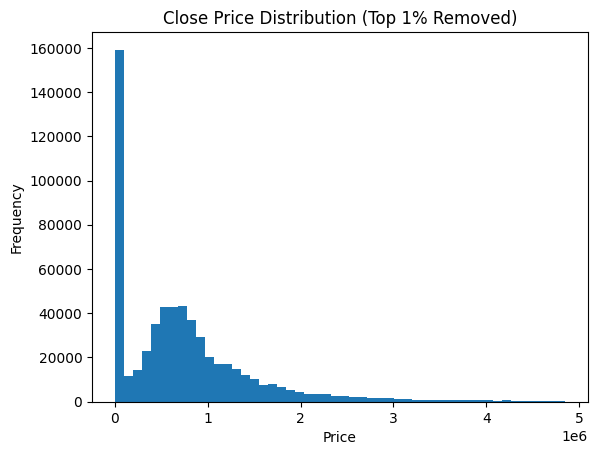

ClosePrice Summary:
count    6.062910e+05
mean     8.224300e+05
std      1.910843e+06
min      0.000000e+00
25%      4.500000e+04
50%      6.200000e+05
75%      1.050000e+06
max      7.486550e+08
Name: ClosePrice, dtype: float64


In [85]:
prices = sold['ClosePrice'].dropna()

upper = prices.quantile(0.99)
prices_filtered = prices[prices <= upper]

plt.figure()
plt.hist(prices_filtered, bins=50)

plt.title("Close Price Distribution (Top 1% Removed)")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

print("ClosePrice Summary:")
print(prices.describe())

### Living Area Distribution

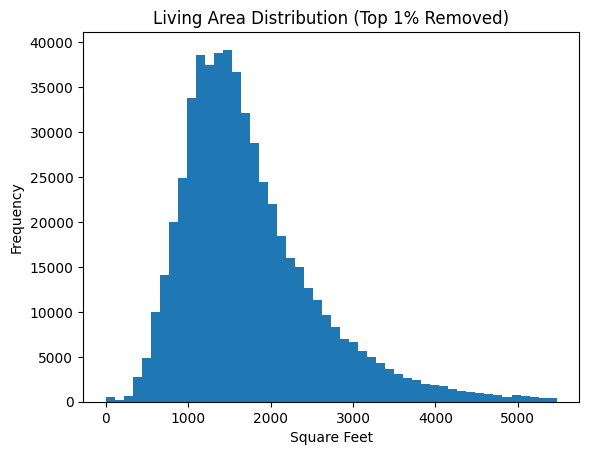

LivingArea Summary:
count    5.626580e+05
mean     3.456418e+03
std      1.212162e+06
min      0.000000e+00
25%      1.180000e+03
50%      1.576000e+03
75%      2.147000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64


In [86]:
living = sold['LivingArea'].dropna()

upper = living.quantile(0.99)
living_filtered = living[living <= upper]

plt.figure()
plt.hist(living_filtered, bins=50)

plt.title("Living Area Distribution (Top 1% Removed)")
plt.xlabel("Square Feet")
plt.ylabel("Frequency")

plt.show()

print("LivingArea Summary:")
print(living.describe())

### Price Per Square Foot

In [87]:
sold['PricePerSqft'] = sold['ClosePrice'] / sold['LivingArea']

print("PricePerSqft sample:")
print(sold[['ClosePrice', 'LivingArea', 'PricePerSqft']].head())

PricePerSqft sample:
   ClosePrice  LivingArea  PricePerSqft
0   1700000.0      3040.0    559.210526
1   1805000.0      3517.0    513.221496
2    625000.0      1092.0    572.344322
3   4350000.0      1696.0   2564.858491
4   1800000.0      2917.0    617.072335


### Price Per Sqft Distribution

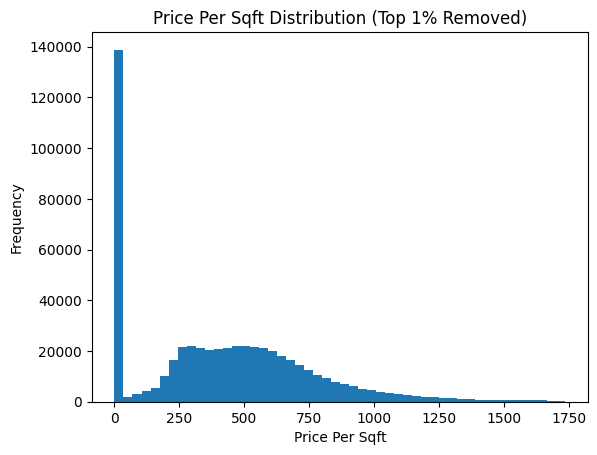

PricePerSqft Summary:
count    5.626500e+05
mean              inf
std               NaN
min      0.000000e+00
25%      6.875000e+01
50%      4.095761e+02
75%      6.398554e+02
max               inf
Name: PricePerSqft, dtype: float64


/Users/sereneqiu/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [88]:
pps = sold['PricePerSqft'].dropna()

upper = pps.quantile(0.99)
pps_filtered = pps[pps <= upper]

plt.figure()
plt.hist(pps_filtered, bins=50)

plt.title("Price Per Sqft Distribution (Top 1% Removed)")
plt.xlabel("Price Per Sqft")
plt.ylabel("Frequency")

plt.show()

print("PricePerSqft Summary:")
print(pps.describe())

The distributions of Close Price, Living Area, and Price Per Square Foot were analyzed.

All variables are right-skewed due to extreme outliers, so the top 1% was removed for better visualization.

Close Price → overall property value
Living Area → property size
Price per Sqft → normalized value across homes

### Log Transformation

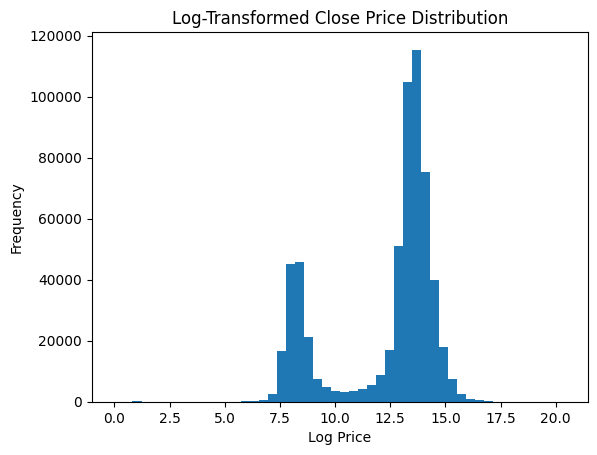

In [89]:
import numpy as np

log_prices = np.log1p(sold['ClosePrice'].dropna())

plt.figure()
plt.hist(log_prices, bins=50)

plt.title("Log-Transformed Close Price Distribution")
plt.xlabel("Log Price")
plt.ylabel("Frequency")

plt.show()

Log transformation reduces skewness and improves visibility across the full price range.

##### Bedrooms Distributions

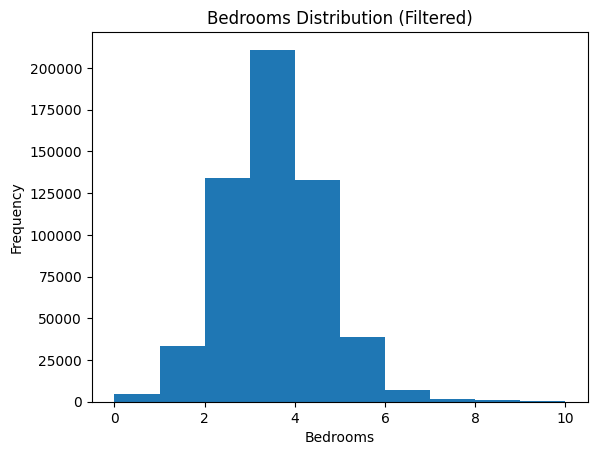

count    565310.000000
mean          3.078302
std           1.433911
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max         132.000000
Name: BedroomsTotal, dtype: float64


In [90]:
bedrooms = sold['BedroomsTotal'].dropna()

# keep only realistic values
bedrooms_filtered = bedrooms[bedrooms <= 10]

plt.figure()
plt.hist(bedrooms_filtered, bins=10)

plt.title("Bedrooms Distribution (Filtered)")
plt.xlabel("Bedrooms")
plt.ylabel("Frequency")

plt.show()

print(bedrooms.describe())

The bedroom distribution initially appeared highly skewed due to extreme outliers (e.g., unusually large bedroom counts).

Filtering unrealistic values improves visualization and highlights the typical range of 2–4 bedrooms.

### Sale-To-List Ratio

In [91]:
sold['SaleToListRatio'] = sold['ClosePrice'] / sold['ListPrice']

print(sold[['ClosePrice', 'ListPrice', 'SaleToListRatio']].head())

   ClosePrice  ListPrice  SaleToListRatio
0   1700000.0  1700000.0             1.00
1   1805000.0  1900000.0             0.95
2    625000.0   625000.0             1.00
3   4350000.0  4350000.0             1.00
4   1800000.0  1800000.0             1.00


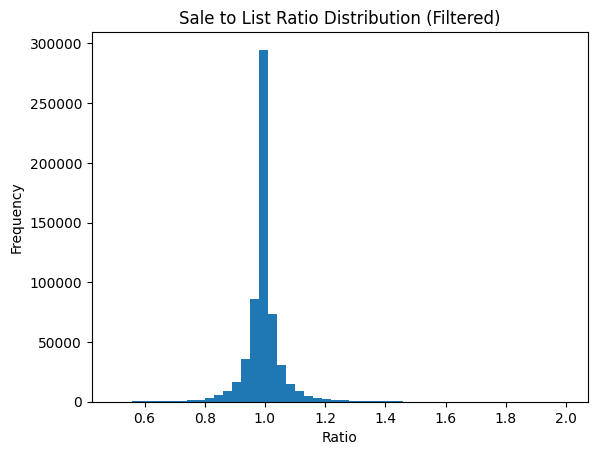

count    603994.000000
mean          0.995763
std           0.069551
min           0.500001
25%           0.976154
50%           1.000000
75%           1.007692
max           1.998183
Name: SaleToListRatio, dtype: float64


In [92]:
import numpy as np

ratio = sold['SaleToListRatio']

# remove inf + NaN
ratio_clean = ratio.replace([np.inf, -np.inf], np.nan).dropna()

# keep only realistic values (THIS IS THE KEY FIX)
ratio_filtered = ratio_clean[(ratio_clean > 0.5) & (ratio_clean < 2)]

plt.figure()
plt.hist(ratio_filtered, bins=50)

plt.title("Sale to List Ratio Distribution (Filtered)")
plt.xlabel("Ratio")
plt.ylabel("Frequency")

plt.show()

print(ratio_filtered.describe())

This metric measures how properties perform relative to their listing price.

### Market Competitiveness

In [93]:
above = (sold['SaleToListRatio'] > 1).mean()
below = (sold['SaleToListRatio'] < 1).mean()

print("Above list %:", round(above * 100, 2))
print("Below list %:", round(below * 100, 2))

Above list %: 30.16
Below list %: 38.61


This shows how competitive the market is by identifying how often homes sell above or below list price.

### Time-Based Analysis

In [94]:
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])

sold['Year'] = sold['CloseDate'].dt.year
sold['Month'] = sold['CloseDate'].dt.month

monthly_prices = sold.groupby(['Year', 'Month'])['ClosePrice'].median().reset_index()

print(monthly_prices.head())

   Year  Month  ClosePrice
0  2024      1    538000.0
1  2024      2    585000.0
2  2024      3    615000.0
3  2024      4    659444.0
4  2024      5    655000.0


### Monthly Price Trends

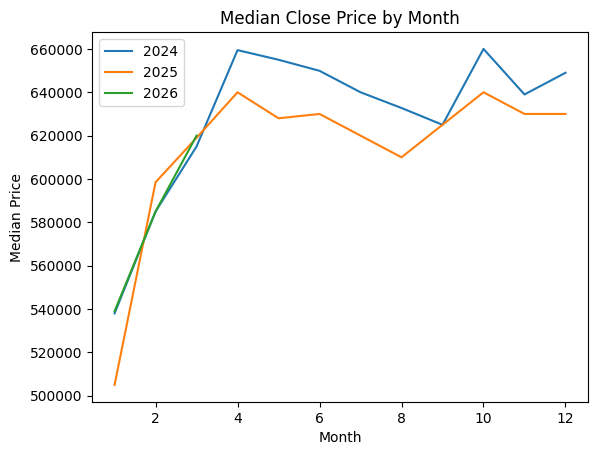

In [95]:
plt.figure()

for year in monthly_prices['Year'].unique():
    subset = monthly_prices[monthly_prices['Year'] == year]
    plt.plot(subset['Month'], subset['ClosePrice'], label=year)

plt.title("Median Close Price by Month")
plt.xlabel("Month")
plt.ylabel("Median Price")
plt.legend()

plt.show()

Monthly trends reveal seasonal patterns and year-over-year changes in pricing.

In [96]:
sold.to_csv("cleaned_sold.csv", index=False)

print("Saved cleaned dataset")

Saved cleaned dataset


Key takeaways:

- Data was filtered to residential properties
- Missing values were identified and evaluated
- Price-related variables are highly skewed
- Feature engineering (PricePerSqft, SaleToListRatio) improves analysis
- Most homes sell near list price
- Seasonal trends exist in pricing

# Week 4 - Market Insights & Business Questions

### Property Type Distribution (Validation Check)

In [97]:
print("PROPERTY TYPE DISTRIBUTION (LISTED):")
property_dist = listed['PropertyType'].value_counts(normalize=True)
print(property_dist)

PROPERTY TYPE DISTRIBUTION (LISTED):
PropertyType
Residential    1.0
Name: proportion, dtype: float64


##### Interpretation
The dataset is heavily dominated by residential properties, which validates focusing analysis on this segment.

- Agents → confirms primary market focus
- Sellers → understand competition type
- Buyers → see what inventory dominates the market

### Pricing Metrics - Mean vs Median Price

In [98]:
print("MEAN CLOSE PRICE:", sold['ClosePrice'].mean())
print("MEDIAN CLOSE PRICE:", sold['ClosePrice'].median())

MEAN CLOSE PRICE: 822429.9796419872
MEDIAN CLOSE PRICE: 620000.0


##### Interpretation
The mean close price is higher than the median, indicating a right-skewed distribution. This suggests that a small number of high-priced properties are pulling the average upward.

##### Cleaned Price Distribution

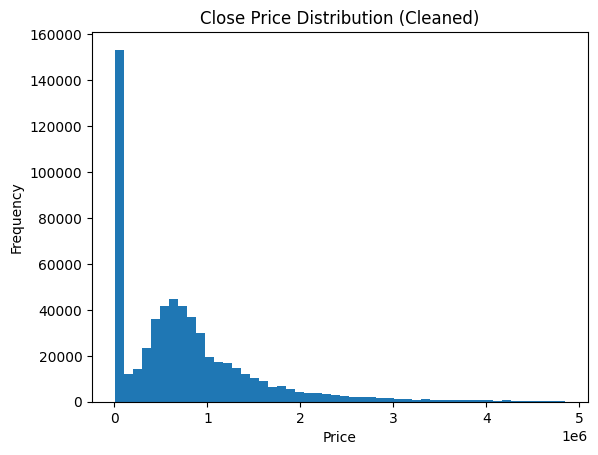

In [99]:
import matplotlib.pyplot as plt

prices = sold['ClosePrice'].dropna()

# Remove extreme outliers (1st–99th percentile)
lower = prices.quantile(0.01)
upper = prices.quantile(0.99)
prices_clean = prices[(prices >= lower) & (prices <= upper)]

plt.figure()
plt.hist(prices_clean, bins=50)
plt.title("Close Price Distribution (Cleaned)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

##### Interpretation

The distribution is highly right-skewed, with a large concentration of homes in the lower to mid price range and a long tail extending toward higher prices. The spike on the left reflects the high frequency of more affordable homes, while the smaller number of expensive properties stretches the distribution to the right.

This indicates that most homes are priced within a typical range, while a few high-value properties act as outliers and increase the overall spread. As a result, the median is a more reliable measure of central tendency than the mean.

From a market perspective, this suggests that the housing market is dominated by mid-range properties, and pricing strategies should focus on comparable homes rather than extreme high-end listings.

### Sale-to-List Ratio (Cleaned)

In [100]:
ratio = sold['SaleToListRatio'].dropna()

# Clean extreme values
ratio_clean = ratio[(ratio > 0.5) & (ratio < 1.5)]

above = (ratio_clean > 1).mean()
below = (ratio_clean < 1).mean()

print("ABOVE LIST %:", above)
print("BELOW LIST %:", below)

ABOVE LIST %: 0.30099780016478045
BELOW LIST %: 0.38677811172245274


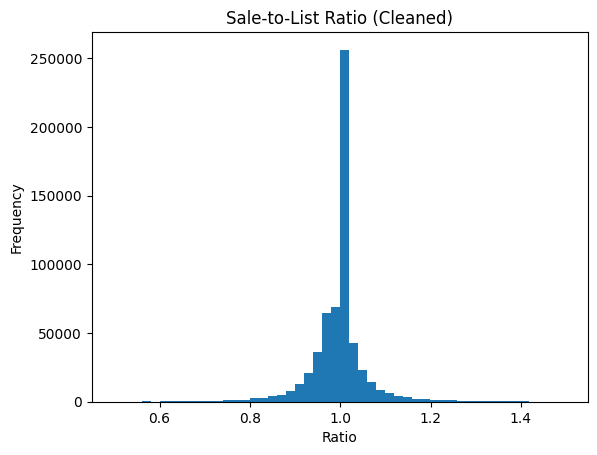

In [101]:
plt.figure()
plt.hist(ratio_clean, bins=50)
plt.title("Sale-to-List Ratio (Cleaned)")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

##### Interpretation
Many homes sell at or above list price
--> Indicates a competitive seller’s market

Stakeholder insight:

- Agents → strong pricing power
- Sellers → can price aggressively
- Buyers → must act quickly / bid competitively

### Days on Market 

In [102]:
# Merge datasets
merged = sold.merge(
    listed[['ListingKey', 'ListingContractDate']],
    on='ListingKey',
    how='left'
)

# Convert dates
merged['CloseDate'] = pd.to_datetime(merged['CloseDate'])
merged['ListingContractDate'] = pd.to_datetime(merged['ListingContractDate'])

# Create DaysOnMarket
merged['DaysOnMarket'] = (
    merged['CloseDate'] - merged['ListingContractDate']
).dt.days

print(merged['DaysOnMarket'].describe())

count    377144.000000
mean         72.282301
std          55.614018
min        -189.000000
25%          37.000000
50%          55.000000
75%          90.000000
max         784.000000
Name: DaysOnMarket, dtype: float64


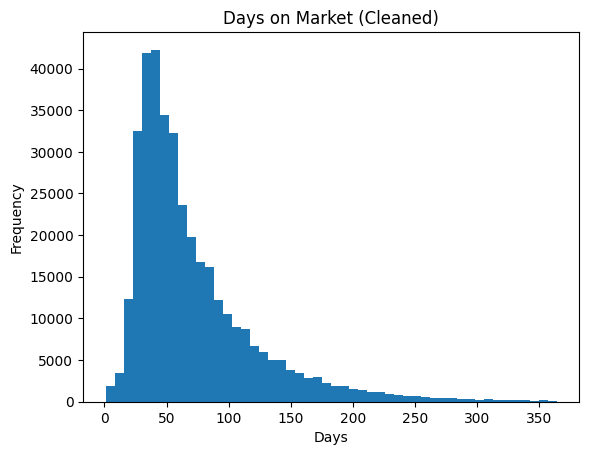

In [103]:
dom = merged['DaysOnMarket'].dropna()
dom_clean = dom[(dom > 0) & (dom < 365)]

plt.figure()
plt.hist(dom_clean, bins=50)
plt.title("Days on Market (Cleaned)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

##### Interpretation
- Most homes sell within a reasonable time window
- Some take much longer → potential pricing or desirability issues

Stakeholder insight:

- Agents → optimize listing timing + pricing
- Sellers → avoid overpricing (leads to longer DOM)
- Buyers → longer DOM = potential negotiation opportunity

### Geographic Pricing Differences 

In [104]:
top_cities = (
    sold.groupby('City')['ClosePrice']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

print(top_cities)

City
Belvedere          9875000.0
Atherton           7107125.0
Montecito          5737500.0
Los Altos Hills    5380500.0
Hidden Hills       5025000.0
Hillsborough       4755000.0
Alpaugh            4728175.0
Monte Sereno       4668000.0
Glennville         4592500.0
Los Altos          4015000.0
Name: ClosePrice, dtype: float64


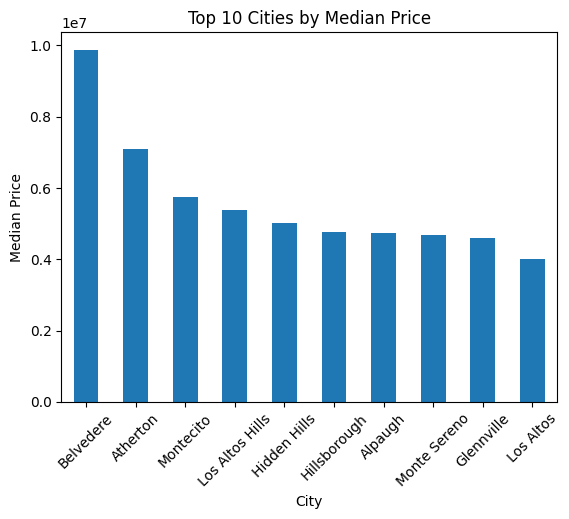

In [105]:
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Median Price")
plt.xlabel("City")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()

##### Interpretation
- Large variation across cities
- Location is a major price driver

Stakeholder insight:

- Agents → tailor pricing strategy by location
- Sellers → understand local competition
- Buyers → identify affordable vs premium areas

### Affordability — Price Per Square Foot

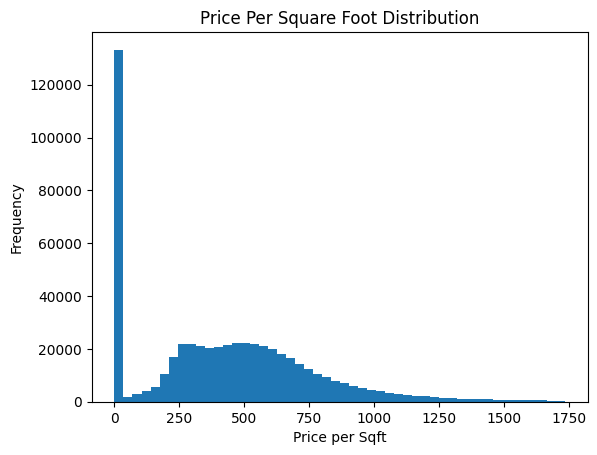

In [106]:
sold['PricePerSqft'] = sold['ClosePrice'] / sold['LivingArea']

ppsf = sold['PricePerSqft'].dropna()
ppsf_clean = ppsf[(ppsf > ppsf.quantile(0.01)) & (ppsf < ppsf.quantile(0.99))]

plt.figure()
plt.hist(ppsf_clean, bins=50)
plt.title("Price Per Square Foot Distribution")
plt.xlabel("Price per Sqft")
plt.ylabel("Frequency")
plt.show()

##### Interpretation
- Normalizes price across property sizes
- Gives a better sense of true value

Stakeholder insight:

- Buyers → compare homes fairly
- Sellers → price competitively
- Agents → identify undervalued listings

### Data Quality Issues 

In [107]:
invalid_dates = merged[merged['CloseDate'] < merged['ListingContractDate']]
print("INVALID DATE RECORDS:", len(invalid_dates))

INVALID DATE RECORDS: 71


##### Interpretation
- Some records contain invalid timelines
- These should be flagged or removed in future steps

##### Summary
##### Key Insights
- Housing prices are right-skewed, driven by high-end outliers
- Most homes sell near or above list price → competitive market
- Location + size are the biggest pricing drivers
- Market speed (Days on Market) reflects pricing accuracy
- Price per square foot reveals true affordability differences
- Dataset is strong but contains minor data quality issues

##### Stakeholder Takeaways

Agents / Brokers

- Use median pricing + PPSF for accurate comps
- Adjust strategy based on location + demand

Home Sellers

- Competitive pricing is critical for faster sales
- Overpricing leads to longer time on market

Home Buyers

- Expect competition in many areas
- Look at PPSF + DOM for better deals

In [108]:
sold.to_csv("final_week4_dataset.csv", index=False)
print("Final dataset saved.")

Final dataset saved.
